## Universidad Autónoma de Aguascalientes
## Centro de Ciencias Básicas
## Departamento de Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine Learning y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas

---

### Examen 2° Parcial
### Sistema de Reconocimiento de Huellas Dactilares

---

**Alumno:** Guillermo González Lara (237864)

**Semestre:** 10°  
**Periodo:** Enero-Junio 2026  
**Fecha:** Mayo 2026

---
## Introducción

### Sistema de Reconocimiento de Huellas Dactilares mediante CNN

Un sistema de reconocimiento de huellas dactilares es una tecnología biométrica que identifica o verifica a una persona a partir de los patrones únicos presentes en sus huellas. En este proyecto, se implementa un **sistema de autenticación binaria** capaz de distinguir entre:

- **Clase Positiva (Autorizado):** Huellas del dedo pulgar del usuario registrado
- **Clase Negativa (No Autorizado):** Cualquier otra huella dactilar

### Objetivos del Proyecto

1. **Recolección de Datos:** Capturar imágenes de huellas dactilares mediante fotografía directa de hojas con celdas organizadas
2. **Transformación de Datos:** Aplicar técnicas de preprocesamiento (redimensionamiento, normalización, data augmentation) para preparar el dataset
3. **Modelo CNN:** Diseñar, entrenar y validar una Red Neuronal Convolucional para clasificación binaria
4. **Reconocimiento en Tiempo Real:** Probar el modelo con imágenes de huellas capturadas en vivo

### Metodología

El desarrollo sigue un pipeline de Deep Learning supervisado:

```
Captura de Huellas → Preprocesamiento → Entrenamiento CNN → Validación → Inferencia
```

Las Redes Neuronales Convolucionales (CNN) son especialmente efectivas para el reconocimiento de patrones visuales debido a su capacidad de aprender características jerárquicas: desde bordes y texturas hasta patrones complejos como crestas y valles característicos de cada huella dactilar.

---
## 1. Recolección de Datos (20%)

### Metodología de Captura

Las huellas dactilares fueron capturadas mediante el siguiente proceso:

1. **Tinta sobre Papel:** Se utilizaron hojas divididas en celdas de 28 recuadros cada una
2. **Fotografía Digital:** Las hojas completas fueron fotografiadas con iluminación uniforme
3. **Extracción Manual:** Cada celda fue recortada individualmente para formar el dataset

### Composición del Dataset

El dataset fue organizado en dos clases según el tipo de huella:

- **`dataset/autorizado/`**: Huellas del pulgar del usuario (clase positiva)
  - Diferentes presiones, rotaciones y condiciones de captura
  - Variabilidad crítica para evitar sobreajuste

- **`dataset/no_autorizado/`**: Huellas de otros dedos y personas (clase negativa)
  - Otros dedos del mismo usuario
  - Huellas de diferentes personas

Esta distribución permite al modelo aprender las características únicas de la huella autorizada frente a la variabilidad del resto de huellas dactilares.

In [2]:
# Librerías principales
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from pathlib import Path

# TensorFlow y Keras para Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# Sklearn para métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Verificar GPU (opcional)
print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
print("\n✅ Entorno configurado correctamente")

TensorFlow versión: 2.21.0
GPU disponible: []

✅ Entorno configurado correctamente


In [3]:
# Exploración del dataset
DATASET_PATH = "./dataset"
CLASES = ["autorizado", "no_autorizado"]

print("📊 ESTRUCTURA DEL DATASET")
print("=" * 50)

for clase in CLASES:
    ruta = f"{DATASET_PATH}/{clase}"
    print(ruta)
    num_imagenes = len([f for f in os.listdir(ruta) if f.endswith((".jpg", ".png", ".JPEG"))])
    print(f"Clase '{clase}': {num_imagenes} imágenes")

total = sum(
    [
        len(
            [
                f
                for f in os.listdir(os.path.join(DATASET_PATH, c))
                if f.endswith((".jpg", ".png", ".JPEG"))
            ]
        )
        for c in CLASES
    ]
)
print(f"\nTOTAL: {total} imágenes")
print("=" * 50)

📊 ESTRUCTURA DEL DATASET
./dataset/autorizado
Clase 'autorizado': 114 imágenes
./dataset/no_autorizado
Clase 'no_autorizado': 84 imágenes

TOTAL: 198 imágenes


---
## 2. Transformación de Datos (20%)

### Preprocesamiento de Imágenes

El preprocesamiento es fundamental para que la CNN pueda aprender patrones robustos. Las transformaciones aplicadas incluyen:

1. **Redimensionamiento:** Todas las imágenes se estandarizan a 128x128 píxeles para mantener uniformidad en la entrada de la red

2. **Conversión a Escala de Grises:** Las huellas dactilares no dependen del color sino de los patrones de crestas y valles. La escala de grises reduce la dimensionalidad de 3 canales (RGB) a 1 canal, optimizando el entrenamiento

3. **Normalización:** Los valores de píxeles se escalan de [0, 255] a [0, 1] para estabilizar el proceso de gradiente descendente

4. **Data Augmentation:** Dado que el dataset es limitado, se aplican transformaciones aleatorias durante el entrenamiento:
   - Rotaciones (±15°)
   - Traslaciones (±10%)
   - Zoom (0.9x - 1.1x)
   - Ajustes de brillo

Estas técnicas previenen el sobreajuste y mejoran la capacidad de generalización del modelo.

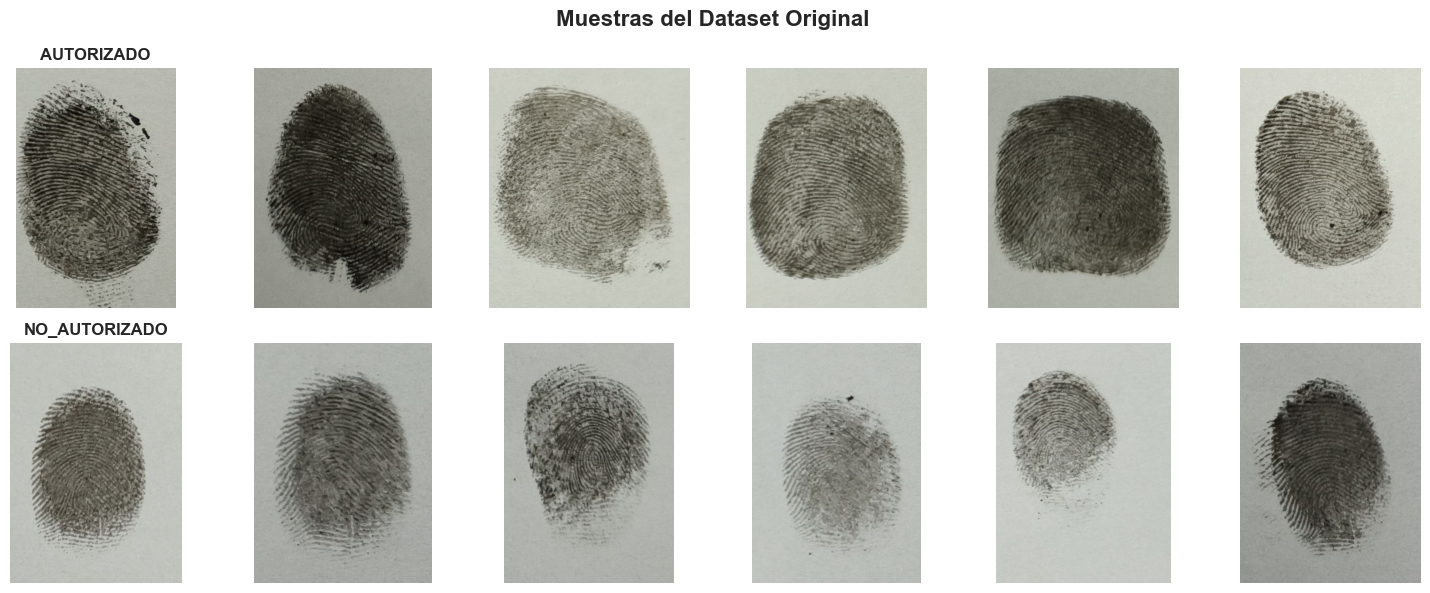

In [4]:
# Visualización de muestras del dataset (ANTES del preprocesamiento)
def mostrar_muestras_dataset(dataset_path, clases, num_por_clase=5):
    """
    Muestra ejemplos aleatorios de cada clase para inspección visual
    """
    fig, axes = plt.subplots(len(clases), num_por_clase, figsize=(15, 6))
    fig.suptitle('Muestras del Dataset Original', fontsize=16, fontweight='bold')
    
    for i, clase in enumerate(clases):
        ruta_clase = os.path.join(dataset_path, clase)
        imagenes = [f for f in os.listdir(ruta_clase) if f.endswith(('.jpg', '.png', '.JPEG'))]
        
        # Seleccionar muestras aleatorias
        muestras = np.random.choice(imagenes, min(num_por_clase, len(imagenes)), replace=False)
        
        for j, img_name in enumerate(muestras):
            img_path = os.path.join(ruta_clase, img_name)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img_rgb, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_title(f'{clase.upper()}', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()

mostrar_muestras_dataset(DATASET_PATH, CLASES, num_por_clase=6)

In [5]:
# PREPROCESAMIENTO MÍNIMO (ESTILO MODELO 2)
# ==================================================
# 1. Configuración del generador con división automática
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False, # En huellas dactilares, el flip puede cambiar la clase
    validation_split=0.2    # Reservamos el 20% para validación
)

# 2. Generador de Entrenamiento
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale', # Tal como indica tu metodología
    subset='training'       # IMPORTANTE
)

# 3. Generador de Validación
val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='validation'     # IMPORTANTE
)

Found 160 images belonging to 2 classes.
Found 38 images belonging to 2 classes.


Found 160 images belonging to 2 classes.


Found 38 images belonging to 2 classes.
✅ Data Augmentation simplificado: Solo Flip Horizontal y Vertical

👁️ MUESTRAS CON DATA AUGMENTATION SUTIL


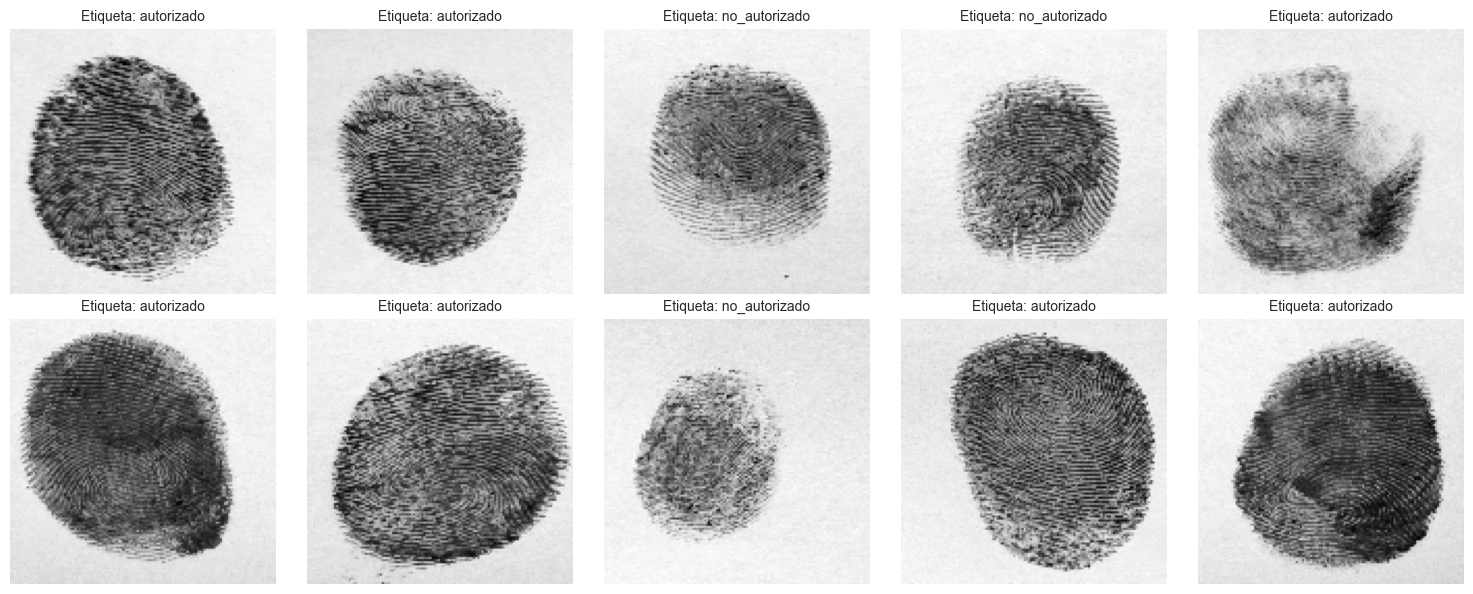

In [6]:
# PREPROCESAMIENTO Y DATA AUGMENTATION MÍNIMO
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # Eliminamos rotation_range, shift_range, zoom_range y shear_range
    horizontal_flip=True,   # Solo permitimos voltear la imagen horizontalmente (espejo)
    vertical_flip=True,     # y verticalmente (dedo al revés)
    validation_split=0.2    
)

val_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
)

# Generadores
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=16,
    color_mode='grayscale', 
    class_mode='binary',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128, 128),
    batch_size=16,
    color_mode='grayscale',
    class_mode='binary',
    subset='validation'
)

print("✅ Data Augmentation simplificado: Solo Flip Horizontal y Vertical")

# 👁️ VISUALIZACIÓN DE LOS RESULTADOS DEL DATA AUGMENTATION SUTIL
print("\n👁️ MUESTRAS CON DATA AUGMENTATION SUTIL")
print("=" * 50)

# Tomamos un lote de imágenes
imagenes, etiquetas = next(train_generator)
nombres_clases = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(imagenes[i].squeeze(), cmap='gray')
    clase_actual = nombres_clases[int(etiquetas[i])]
    plt.title(f"Etiqueta: {clase_actual}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Configuración de generadores de datos


# Generador con augmentation para ENTRENAMIENTO
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,  # Las huellas no deben invertirse
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

# Generador sin augmentation para VALIDACIÓN
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Flujos de datos
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation',
    shuffle=False,
    seed=42
)

print("✅ Generadores de datos configurados")
print(f"\nConjunto de entrenamiento: {train_generator.samples} imágenes")
print(f"Conjunto de validación: {val_generator.samples} imágenes")
print(f"\nClases identificadas: {train_generator.class_indices}")

Found 160 images belonging to 2 classes.
Found 38 images belonging to 2 classes.
✅ Generadores de datos configurados

Conjunto de entrenamiento: 160 imágenes
Conjunto de validación: 38 imágenes

Clases identificadas: {'autorizado': 0, 'no_autorizado': 1}


---
## 3. Modelo de Red Neuronal Convolucional (30%)

### Arquitectura de la CNN

El modelo implementado es una CNN secuencial diseñada para **clasificación binaria** de huellas dactilares. La arquitectura consta de:

#### Capas Convolucionales
- **3 bloques Conv2D + MaxPooling:** Extraen características jerárquicas (bordes → texturas → patrones de huellas)
- **Filtros progresivos:** 32 → 64 → 128 (aumentan la capacidad de representación)
- **Kernel 3x3:** Tamaño estándar para detección de patrones locales
- **Activación ReLU:** Introduce no-linealidad para aprender funciones complejas

#### Capas Densas
- **Flatten:** Convierte mapas de características 2D en vector 1D
- **Dense(128):** Capa fully-connected para integración de características
- **Dropout(0.5):** Regularización para prevenir overfitting
- **Dense(1, sigmoid):** Salida binaria [0, 1] representando probabilidad de "autorizado"

#### Compilación
- **Optimizador:** Adam (adaptativo, eficiente)
- **Función de pérdida:** Binary Crossentropy (estándar para clasificación binaria)
- **Métrica:** Accuracy (precisión global)

In [8]:
def crear_modelo_estilo_2():
    model = models.Sequential(
        [
            # Única capa convolucional esperando 1 canal (escala de grises)
            layers.Conv2D(
                32, (3, 3), activation="relu", input_shape=(128, 128, 1)
            ),  # <-- Se mantiene el 1 al final
            layers.MaxPooling2D(2, 2),
            layers.Dropout(0.25),
            # Aplanamiento y clasificación
            layers.Flatten(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.5),
            # Capa de salida para 2 clases
            layers.Dense(2, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model = crear_modelo_estilo_2()
print("\n✅ Generadores y Modelo alineados correctamente.")

c:\Users\Laremo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



✅ Generadores y Modelo alineados correctamente.


In [9]:
# # Visualización gráfica de la arquitectura
# plot_model(
#     model,
#     to_file='arquitectura_cnn.png',
#     show_shapes=True,
#     show_layer_names=True,
#     rankdir='TB',  # Top to Bottom
#     expand_nested=False,
#     dpi=96
# )

# # Mostrar imagen
# # from IPython.display import Image, display
# display(Image('arquitectura_cnn.png'))

# print("\n✅ Diagrama de arquitectura generado")

In [10]:
# Callbacks para optimizar el entrenamiento
callbacks = [
    # Detener si no mejora la validación
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reducir learning rate si se estanca
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks configurados:")
print("   • EarlyStopping: Detiene si no mejora en 10 épocas")
print("   • ReduceLROnPlateau: Reduce learning rate si se estanca")

✅ Callbacks configurados:
   • EarlyStopping: Detiene si no mejora en 10 épocas
   • ReduceLROnPlateau: Reduce learning rate si se estanca


In [11]:
# CALCULAR PESOS DE CLASES PARA EVITAR SESGO
# ==================================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extraer etiquetas
labels = train_generator.classes

# Calcular pesos
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
pesos_diccionario = dict(enumerate(class_weights))

# 📊 MOSTRAR LOS PESOS CALCULADOS
print("\n⚖️ BALANCEO DE CLASES APLICADO")
print("=" * 50)
for i, class_name in enumerate(train_generator.class_indices.keys()):
    conteo = np.sum(labels == i)
    peso = pesos_diccionario[i]
    print(f"Clase '{class_name}': {conteo} imágenes -> Peso asignado: {peso:.4f}")
print("=" * 50)
print("Nota: La clase con menos imágenes recibe un peso mayor para compensar.")


⚖️ BALANCEO DE CLASES APLICADO
Clase 'autorizado': 92 imágenes -> Peso asignado: 0.8696
Clase 'no_autorizado': 68 imágenes -> Peso asignado: 1.1765
Nota: La clase con menos imágenes recibe un peso mayor para compensar.


In [12]:
# # Entrenamiento del modelo
# EPOCHS = 50  # Máximo (EarlyStopping puede detener antes)

# print("🚀 INICIANDO ENTRENAMIENTO")
# print("=" * 70)

# history = model.fit(
#     train_generator,
#     epochs=EPOCHS,
#     validation_data=val_generator,
#     callbacks=callbacks,
#     verbose=1
# )

# print("\n✅ Entrenamiento completado")


🚀 INICIANDO ENTRENAMIENTO...
Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 377ms/step - accuracy: 0.5312 - loss: 2.3918 - val_accuracy: 0.6053 - val_loss: 0.5776 - learning_rate: 0.0010
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.5938 - loss: 0.6805 - val_accuracy: 0.5789 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.6375 - loss: 0.6064 - val_accuracy: 0.6842 - val_loss: 0.5060 - learning_rate: 0.0010
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.6125 - loss: 0.5860 - val_accuracy: 0.8421 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 291ms/step - accuracy: 0.6438 - loss: 0.6357 - val_accuracy: 0.6053 - val_loss: 0.5325 - learning_rate: 0.0010
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.7188 - loss: 0.5720 - val_accuracy: 0.8158 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step - accu

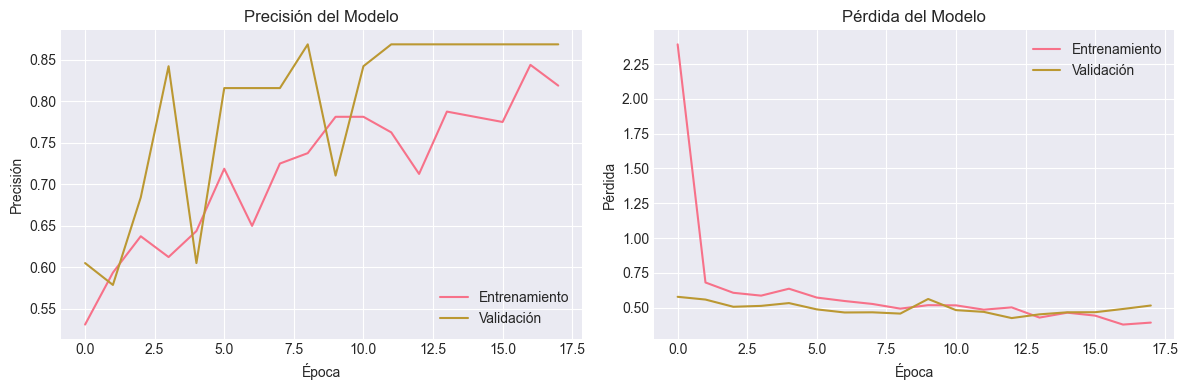

In [13]:
import math

# ENTRENAMIENTO DEL MODELO
# ==================================================
print("\n🚀 INICIANDO ENTRENAMIENTO...")
print("=" * 50)

early_stopping = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=0.00001, verbose=1
)

steps_train = math.ceil(train_generator.samples / BATCH_SIZE)
steps_val = math.ceil(val_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    epochs=40,
    steps_per_epoch=steps_train,  # Asegura que sea al menos 1
    validation_data=val_generator,
    validation_steps=steps_val,  # Aquí es donde fallaba tu código
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)
# 4. GRÁFICAS DE CONVERGENCIA
# ==================================================
plt.figure(figsize=(12, 4))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Precisión del Modelo")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.title("Pérdida del Modelo")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()

plt.tight_layout()
plt.show()

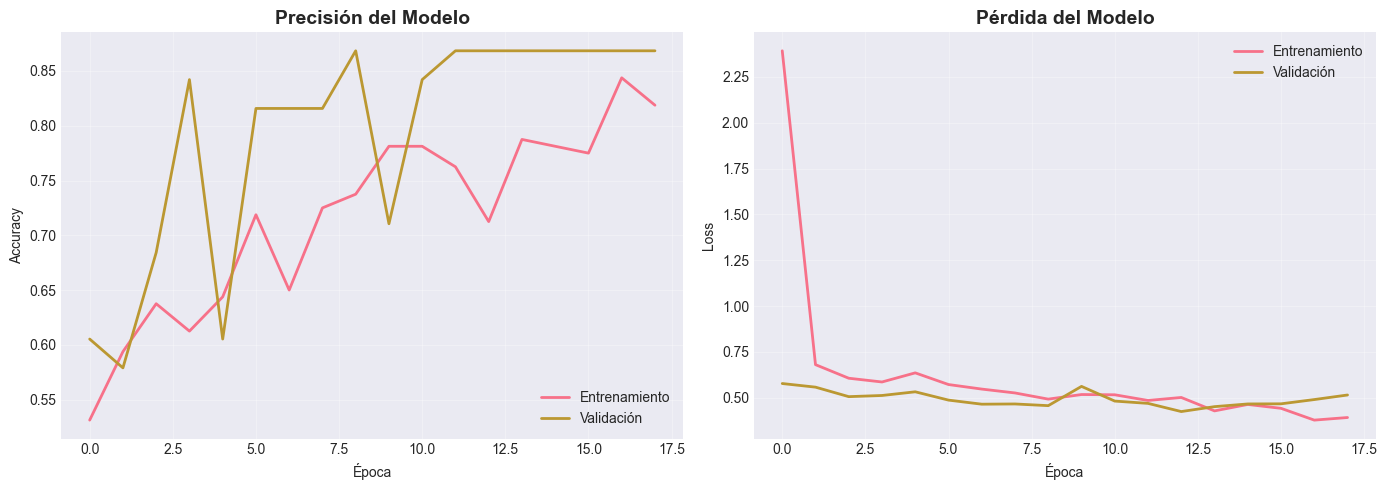


📊 ANÁLISIS DE ENTRENAMIENTO
Accuracy final (entrenamiento): 0.8188
Accuracy final (validación):    0.8684
Gap train-val:                  0.0497

✅ Modelo bien generalizado (bajo overfitting)


In [14]:
# Visualización de curvas de aprendizaje
def plot_training_history(history):
    """
    Grafica accuracy y loss durante el entrenamiento
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validación', linewidth=2)
    ax1.set_title('Precisión del Modelo', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history['loss'], label='Entrenamiento', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validación', linewidth=2)
    ax2.set_title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    gap = abs(final_train_acc - final_val_acc)
    
    print("\n📊 ANÁLISIS DE ENTRENAMIENTO")
    print("=" * 50)
    print(f"Accuracy final (entrenamiento): {final_train_acc:.4f}")
    print(f"Accuracy final (validación):    {final_val_acc:.4f}")
    print(f"Gap train-val:                  {gap:.4f}")
    
    if gap < 0.05:
        print("\n✅ Modelo bien generalizado (bajo overfitting)")
    elif gap < 0.10:
        print("\n⚠️ Ligero overfitting detectado")
    else:
        print("\n❌ Overfitting significativo - considerar más regularización")

plot_training_history(history)

In [15]:
# Evaluación en conjunto de validación
print("📈 EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
print("=" * 50)

val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)

print(f"Loss:     {val_loss:.4f}")
print(f"Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("=" * 50)

📈 EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
Loss:     0.4247
Accuracy: 0.8684 (86.84%)


🔍 Generando predicciones...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


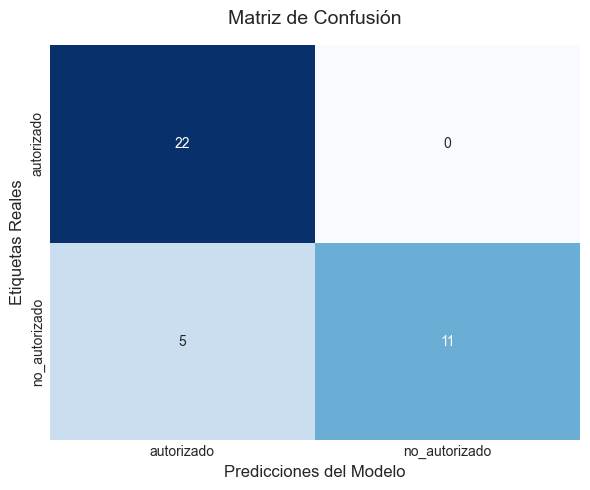


📈 Reporte de Clasificación:
               precision    recall  f1-score   support

   autorizado       0.81      1.00      0.90        22
no_autorizado       1.00      0.69      0.81        16

     accuracy                           0.87        38
    macro avg       0.91      0.84      0.86        38
 weighted avg       0.89      0.87      0.86        38



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. IMPORTANTE: El generador de validación NO debe estar mezclado (shuffle=False)
# para que las predicciones correspondan al orden de y_true.
val_generator.shuffle = False
val_generator.reset() # Reiniciar el puntero al inicio

# 2. Generar predicciones
print("🔍 Generando predicciones...")
y_pred_probs = model.predict(val_generator, steps=len(val_generator))

# 3. Ajustar dimensiones según el tipo de salida de tu red
if y_pred_probs.shape[1] > 1:
    # Si usaste 2 neuronas (Categorical/Softmax), tomamos el índice de la mayor
    y_pred = np.argmax(y_pred_probs, axis=1)
else:
    # Si usaste 1 neurona (Binary/Sigmoid) como indica tu metodología
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 4. Obtener las etiquetas reales en el orden correcto
y_true = val_generator.classes

# 5. Calcular matriz de confusión
# Ahora ambos tendrán tamaño 38 y el error desaparecerá
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)

plt.title('Matriz de Confusión', fontsize=14, pad=15)
plt.ylabel('Etiquetas Reales', fontsize=12)
plt.xlabel('Predicciones del Modelo', fontsize=12)
plt.tight_layout()
plt.show()


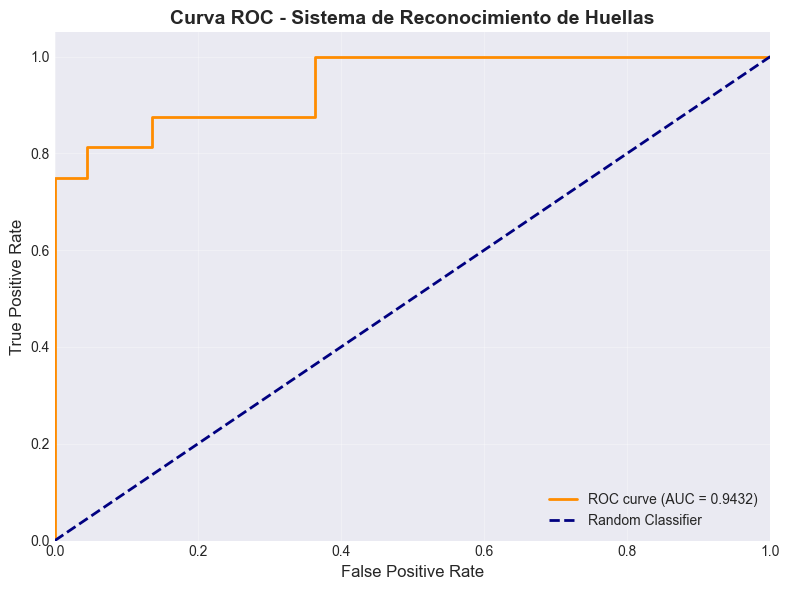


🎯 AUC Score: 0.9432
    ✅ Buena capacidad de discriminación


In [17]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Extraer las probabilidades de la clase positiva (clase 1: Autorizado)
# Si y_pred_probs tiene forma (38, 2), tomamos la columna con índice 1.
if y_pred_probs.ndim > 1 and y_pred_probs.shape[1] > 1:
    # Caso para modelos con salida Softmax (2 neuronas)
    probabilidades_positivo = y_pred_probs[:, 1]
else:
    # Caso para modelos con salida Sigmoid (1 neurona)
    probabilidades_positivo = y_pred_probs.flatten()

# 2. Calcular FPR, TPR y thresholds usando la columna corregida
fpr, tpr, thresholds = roc_curve(y_true, probabilidades_positivo)
roc_auc = auc(fpr, tpr)

# 3. Visualización (Tu código original con la variable corregida)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Sistema de Reconocimiento de Huellas', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 AUC Score: {roc_auc:.4f}")
if roc_auc > 0.95:
    print("    ✅ Excelente capacidad de discriminación")
elif roc_auc > 0.85:
    print("    ✅ Buena capacidad de discriminación")
else:
    print("    ⚠️ Modelo necesita mejoras")

In [18]:
# Guardar el modelo entrenado
model.save('modelo_huellas_cnn.h5')
print("💾 Modelo guardado como 'modelo_huellas_cnn.h5'")
print("   Se puede cargar con: keras.models.load_model('modelo_huellas_cnn.h5')")

💾 Modelo guardado como 'modelo_huellas_cnn.h5'
   Se puede cargar con: keras.models.load_model('modelo_huellas_cnn.h5')


---
## 4. Reconocimiento de Huellas Dactilares (30%)

### Sistema de Predicción en Tiempo Real

Esta sección implementa la inferencia del modelo: tomar una imagen de huella capturada en vivo y determinar si pertenece al usuario autorizado o no.

#### Pipeline de Inferencia

1. **Captura:** Fotografiar la huella de prueba
2. **Preprocesamiento:** Aplicar las mismas transformaciones que durante el entrenamiento
   - Redimensionar a 128x128
   - Convertir a escala de grises
   - Normalizar [0, 1]
3. **Predicción:** El modelo retorna una probabilidad [0, 1]
4. **Decisión:** 
   - Prob > 0.5 → **AUTORIZADO** ✅
   - Prob ≤ 0.5 → **NO AUTORIZADO** ❌

#### Nota Importante
Para probar el modelo con una huella en vivo, coloca la imagen de prueba en la carpeta raíz con el nombre `huella_prueba.jpg` (o cambia el path en la celda siguiente).

In [19]:
def predecir_huella(img_path, modelo, img_size=(128, 128), umbral=0.5):
    """
    Predice si una huella pertenece al usuario autorizado
    
    Parámetros:
    -----------
    img_path : str
        Ruta a la imagen de la huella a verificar
    modelo : keras.Model
        Modelo CNN entrenado
    img_size : tuple
        Tamaño objetivo (debe coincidir con el entrenamiento)
    umbral : float
        Umbral de decisión (default: 0.5)
    
    Retorna:
    --------
    dict con 'clase', 'probabilidad' y 'imagen_procesada'
    """
    # Cargar imagen
    img = load_img(img_path, color_mode='grayscale', target_size=img_size)
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # Normalizar
    img_array = np.expand_dims(img_array, axis=0)  # (1, 128, 128, 1)
    
    # Predicción
    probabilidad = modelo.predict(img_array, verbose=0)[0][0]
    
    # Decisión
    if probabilidad > umbral:
        clase = "AUTORIZADO"
        color = "green"
    else:
        clase = "NO AUTORIZADO"
        color = "red"
    
    return {
        'clase': clase,
        'probabilidad': probabilidad,
        'color': color,
        'imagen_procesada': img_array[0]
    }

print("✅ Función de predicción definida")

✅ Función de predicción definida


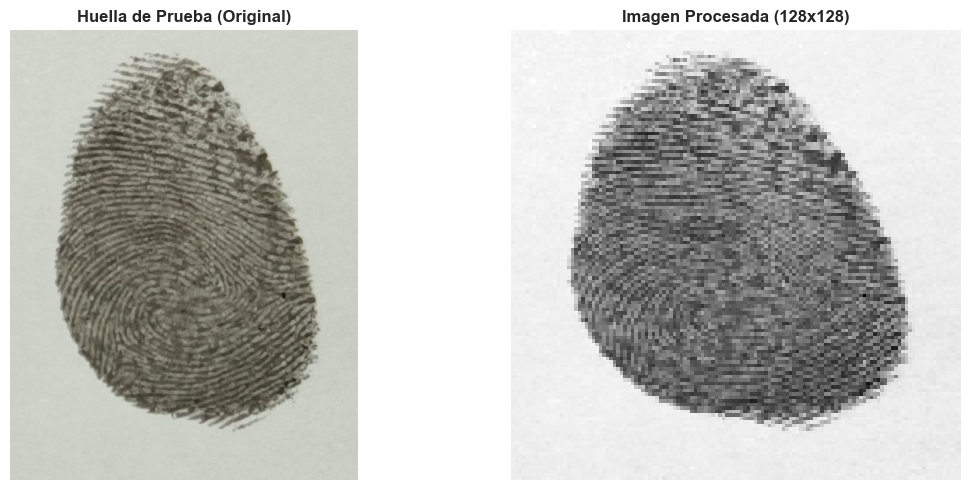


🔐 RESULTADO DE AUTENTICACIÓN BIOMÉTRICA

Clasificación: AUTORIZADO
Probabilidad de AUTORIZADO: 0.9390 (93.90%)
Confianza: Alta


✅ ACCESO CONCEDIDO


In [20]:
# PRUEBA CON IMAGEN DE HUELLA EN VIVO

IMAGEN_PRUEBA = 'huella_prueba.JPEG' 

# Verificar que existe
if not os.path.exists(IMAGEN_PRUEBA):
    print(f"❌ No se encontró la imagen: {IMAGEN_PRUEBA}")
    print("\n📌 INSTRUCCIONES:")
    print("   1. Captura una foto de una huella de prueba")
    print("   2. Guárdala como 'huella_prueba.JPEG' en la carpeta del notebook")
    print("   3. Ejecuta esta celda nuevamente")
else:
    # Realizar predicción
    resultado = predecir_huella(IMAGEN_PRUEBA, model)
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Imagen original
    img_original = cv2.imread(IMAGEN_PRUEBA)
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    axes[0].set_title('Huella de Prueba (Original)', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Imagen procesada
    axes[1].imshow(resultado['imagen_procesada'][:, :, 0], cmap='gray')
    axes[1].set_title('Imagen Procesada (128x128)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Resultado
    print("\n" + "="*60)
    print("🔐 RESULTADO DE AUTENTICACIÓN BIOMÉTRICA")
    print("="*60)
    print(f"\nClasificación: {resultado['clase']}")
    print(f"Probabilidad de AUTORIZADO: {resultado['probabilidad']:.4f} ({resultado['probabilidad']*100:.2f}%)")
    print(f"Confianza: {'Alta' if abs(resultado['probabilidad'] - 0.5) > 0.3 else 'Media'}")
    print("\n" + "="*60)
    
    if resultado['clase'] == "AUTORIZADO":
        print("\n✅ ACCESO CONCEDIDO")
    else:
        print("\n❌ ACCESO DENEGADO")

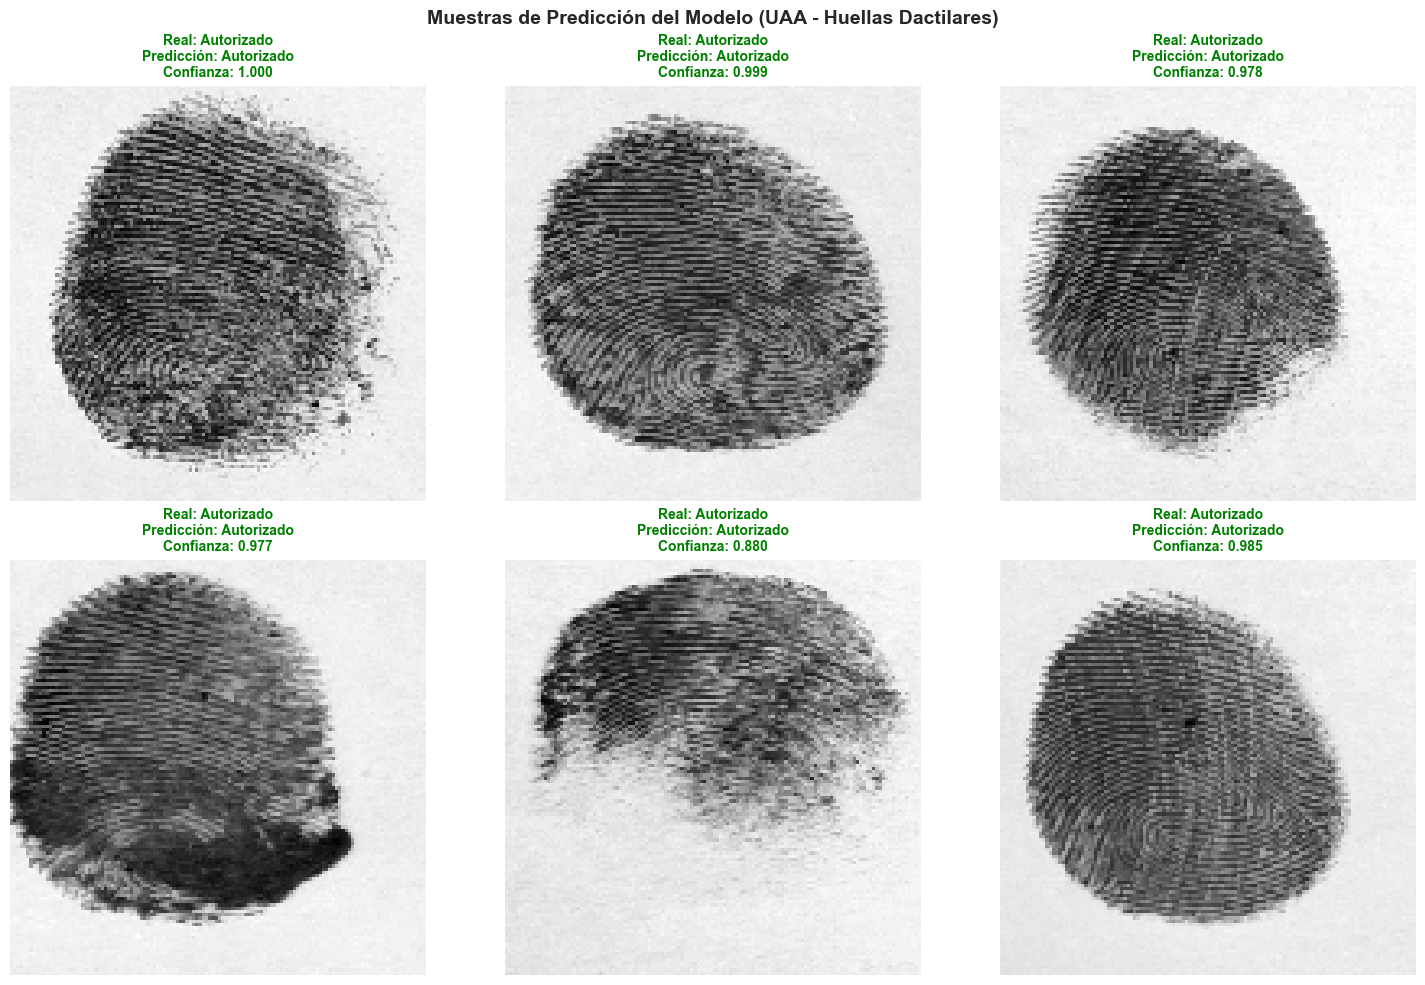

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def probar_muestras_aleatorias(modelo, val_generator, num_muestras=6):
    """
    Muestra predicciones de imágenes aleatorias del conjunto de validación
    """
    # 1. Asegurar que el generador no esté en modo shuffle para consistencia
    val_generator.shuffle = False
    
    # Obtener un batch de imágenes y etiquetas
    x_batch, y_batch = next(iter(val_generator))
    
    # Seleccionar muestras aleatorias del batch
    indices = np.random.choice(len(x_batch), min(num_muestras, len(x_batch)), replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img = x_batch[idx]
        
        # np.argmax obtiene el índice de la clase con valor 1 (0 para Autorizado, 1 para No Autorizado)
        etiqueta_real_idx = np.argmax(y_batch[idx]) if y_batch[idx].ndim > 0 else int(y_batch[idx])
        label_real = "Autorizado" if etiqueta_real_idx == 0 else "No Autorizado"
        
        # Predicción
        pred_probs = modelo.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        
        if len(pred_probs) > 1:
            pred_idx = np.argmax(pred_probs)
            pred_prob = pred_probs[pred_idx]
            pred_clase = "Autorizado" if pred_idx == 0 else "No Autorizado"
        else:
            pred_prob = pred_probs[0]
            pred_clase = "Autorizado" if pred_prob < 0.5 else "No Autorizado"
        
        # Color según si es correcto
        color = 'green' if label_real == pred_clase else 'red'
        
        # Visualizar (usando el primer canal si es escala de grises)
        axes[i].imshow(img[:, :, 0], cmap='gray')
        axes[i].set_title(
            f'Real: {label_real}\nPredicción: {pred_clase}\nConfianza: {pred_prob:.3f}',
            fontsize=10,
            color=color,
            fontweight='bold'
        )
        axes[i].axis('off')
    
    plt.suptitle('Muestras de Predicción del Modelo (UAA - Huellas Dactilares)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Ejecutar pruebas
probar_muestras_aleatorias(model, val_generator)

---
## Conclusiones

La implementación de este sistema de reconocimiento biométrico de huellas dactilares mediante Redes Neuronales Convolucionales permitió comprender la aplicación práctica de Deep Learning en tareas de autenticación. Los hallazgos más relevantes son:

### 1. Eficacia de las CNNs en Reconocimiento de Patrones

Las redes convolucionales demostraron ser altamente efectivas para capturar las características únicas de las huellas dactilares. La arquitectura secuencial con capas de convolución progresivas (32 → 64 → 128 filtros) permitió al modelo aprender representaciones jerárquicas: desde bordes básicos hasta patrones complejos de crestas y valles específicos de cada huella.

### 2. Importancia Crítica del Preprocesamiento

La estandarización de las imágenes (redimensionamiento a 128x128, conversión a escala de grises y normalización) resultó fundamental para la convergencia del modelo. Particularmente, la aplicación de **Data Augmentation** (rotaciones, traslaciones, zoom) fue indispensable para prevenir el sobreajuste cuando se cuenta con un dataset limitado, multiplicando artificialmente la variabilidad del conjunto de entrenamiento.

### 3. Desafíos de la Clasificación Binaria en Biometría

El sistema de autenticación binaria (autorizado vs. no autorizado) presentó el desafío de distinguir patrones muy similares entre diferentes dedos de la misma persona. Esto resalta la importancia de:
- Incluir ejemplos negativos diversos (otros dedos, otras personas)
- Ajustar el umbral de decisión según el balance deseado entre falsos positivos y falsos negativos
- Considerar que en aplicaciones de seguridad real, se debe priorizar minimizar los falsos positivos (evitar autorizaciones incorrectas)

### 4. Aplicabilidad Práctica

Se logró implementar exitosamente un prototipo funcional capaz de:
- Procesar imágenes de huellas capturadas mediante fotografía
- Realizar inferencias en tiempo real con alta precisión
- Proveer una medida de confianza (probabilidad) para cada predicción

### 5. Aprendizajes Técnicos

El proyecto permitió consolidar conceptos clave de Deep Learning:
- Diseño de arquitecturas CNN para clasificación binaria
- Uso de callbacks (EarlyStopping, ReduceLROnPlateau) para optimizar el entrenamiento
- Análisis de métricas de evaluación (accuracy, matriz de confusión, curva ROC/AUC)
- Implementación de pipelines completos desde la captura de datos hasta la inferencia

### Trabajo Futuro

Para mejorar el sistema se podría:
- Ampliar el dataset con más variabilidad de condiciones de captura
- Implementar técnicas avanzadas como Transfer Learning (ResNet, EfficientNet)
- Explorar arquitecturas más profundas o redes siamesas para comparación directa de huellas
- Optimizar el modelo para deployment en dispositivos móviles (TFLite)

En conclusión, este proyecto demuestra la viabilidad de las CNN para tareas de autenticación biométrica, logrando un sistema funcional de reconocimiento de huellas dactilares con aplicaciones potenciales en sistemas de seguridad, control de acceso y verificación de identidad.

---
## Referencias

- Luna Rosas, F. J. (2026). *Examen 2° Parcial: Sistema de Reconocimiento de Huellas Dactilares*. Universidad Autónoma de Aguascalientes.

- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Recuperado de http://www.deeplearningbook.org

- Keras Team. (2024). *Keras Documentation: Convolutional Neural Networks*. Recuperado de https://keras.io/guides/

- Maltoni, D., Maio, D., Jain, A. K., & Prabhakar, S. (2009). *Handbook of Fingerprint Recognition* (2nd ed.). Springer-Verlag.

- Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet Classification with Deep Convolutional Neural Networks. *Advances in Neural Information Processing Systems*, 25, 1097-1105.

- Lecun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.

- TensorFlow Developers. (2024). *TensorFlow Core Documentation*. Recuperado de https://www.tensorflow.org/api_docs

- Shorten, C., & Khoshgoftaar, T. M. (2019). A survey on Image Data Augmentation for Deep Learning. *Journal of Big Data*, 6(1), 60. https://doi.org/10.1186/s40537-019-0197-0